**Install SHAP**

In [ ]:
!pip install -q shap

**Import the required libraries**

In [ ]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Upload the file**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving master_features.csv to master_features.csv


**Load the feature dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("master_features.csv")

**Display the working directory contents**

In [ ]:
import os
print(os.listdir())

['.config', 'master_features.csv', 'drive', 'sample_data']


**Preview the dataset**

In [ ]:
import pandas as pd

df = pd.read_csv("master_features.csv")
df.head()

,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0,0,0,0,0,0,0,0,0,0


**Locate the trained model**

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

/content/drive/MyDrive/RandomForest_model.pkl
/content/drive/MyDrive/Notebook4_Output/RandomForest_model.pkl


**Load the trained Random Forest model**

In [ ]:
import joblib

rf = joblib.load("/content/drive/MyDrive/Notebook4_Output/RandomForest_model.pkl")
print(type(rf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


**Separate predictors and target labels**

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

**Create the SHAP explainer**

In [ ]:
X_sample = X.sample(500, random_state=42)

**Calculate SHAP values**

In [ ]:
shap_values = explainer.shap_values(X_sample, check_additivity=False)

KeyboardInterrupt: 

**Plot the SHAP summary plot**

In [ ]:
shap.summary_plot(shap_values, X_sample)

**Check the SHAP output**

In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(200, 2054, 2)


**Generate the SHAP beeswarm plot**

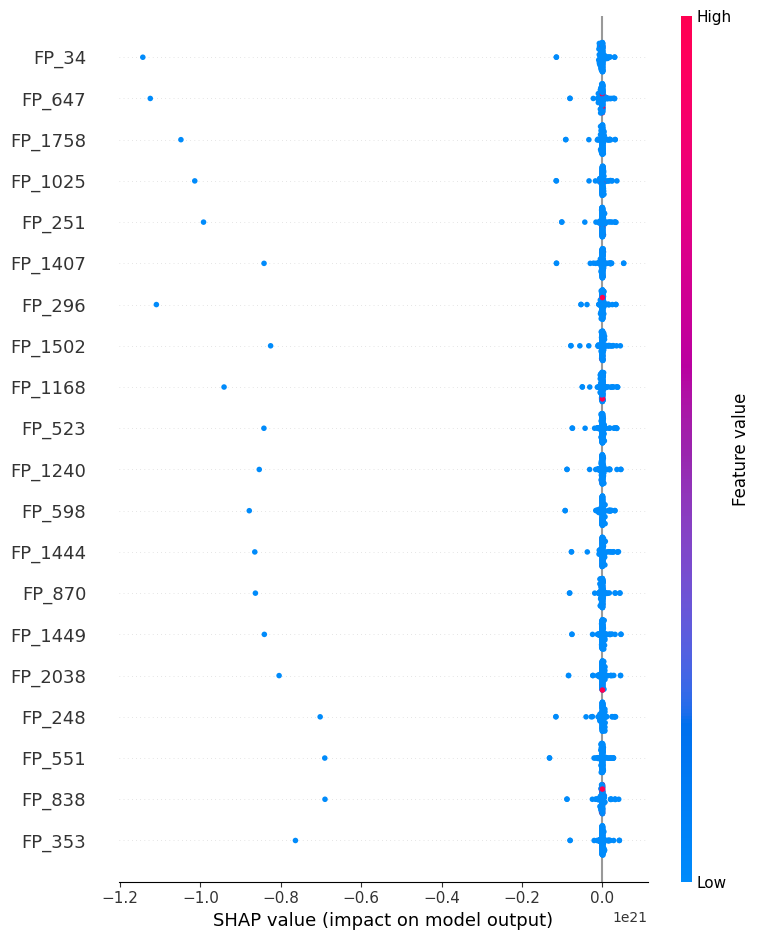

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    max_display=20
)

**Generate the SHAP bar plot**

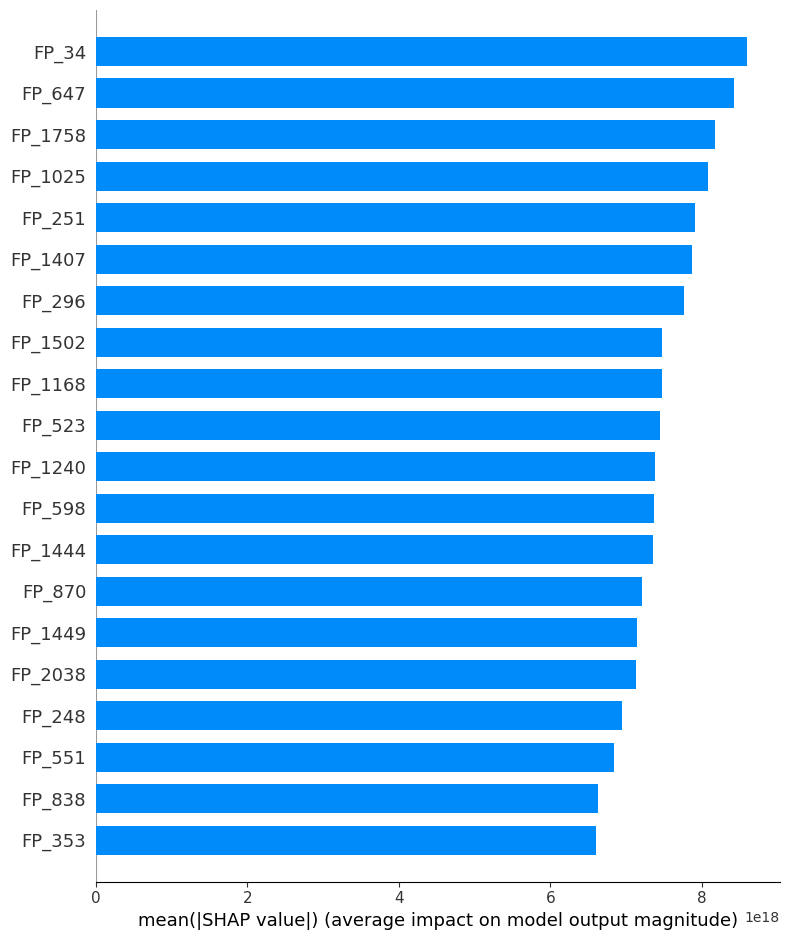

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar",
    max_display=20
)